<a href="https://colab.research.google.com/github/Aggarwal45/brain-tumor-detection/blob/main/brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import shutil
import glob

In [2]:
!file "/content/Brain Tumor Data Set.zip"

/content/Brain Tumor Data Set.zip: Zip archive data, at least v2.0 to extract, compression method=store


In [3]:
import shutil
import os

zip_file_path = '/content/Brain Tumor Data Set.zip'
extract_dir = '/content/BrainTumorData'

if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)
os.makedirs(extract_dir, exist_ok=True)

!unzip -q "{zip_file_path}" -d "{extract_dir}"

print(f'Successfully unzipped {zip_file_path} to {extract_dir}')

Successfully unzipped /content/Brain Tumor Data Set.zip to /content/BrainTumorData


In [4]:
ROOT_DIR = "/content/BrainTumorData/Brain Tumor Data Set"
number_of_images = {}

if not os.path.exists(ROOT_DIR):
    print(f"Error: The directory '{ROOT_DIR}' was not found.")
    print("This usually happens if the zip file '/content/Brain Tumor Data Set.zip' was not correctly uploaded or the 'unzip' command in a previous cell failed.")
    print("Please ensure 'Brain Tumor Data Set.zip' is uploaded to the '/content/' directory and re-run the cell that performs the unzipping, then re-run this cell.")
else:
    for dir_name in os.listdir(ROOT_DIR):

        full_path = os.path.join(ROOT_DIR, dir_name)
        if os.path.isdir(full_path):
            number_of_images[dir_name] = len(os.listdir(full_path))
        else:
            print(f"Warning: '{full_path}' is not a directory and will be skipped.")

    if number_of_images:
        print("Number of images per directory:")
        for item in number_of_images.items():
            print(item)
    else:
        print(f"No directories found in '{ROOT_DIR}' or no images counted.")

Number of images per directory:
('Healthy', 2087)
('Brain Tumor', 2513)


Split data


In [5]:
def dataFolder(p, split):
    # we create a training folder

    # Ensure the target directory for this split is clean before population
    if os.path.exists("./"+p):
        shutil.rmtree("./"+p)
    os.mkdir("./"+p)

    for dir in os.listdir(ROOT_DIR):
        os.makedirs("./"+p+"/"+dir)
        # Calculate the number of images to select for this split
        num_images_to_select = math.floor(split * number_of_images[dir])

        # Get all image files for the current class in ROOT_DIR
        all_images_in_class = [f for f in os.listdir(os.path.join(ROOT_DIR, dir)) if os.path.isfile(os.path.join(ROOT_DIR, dir, f))]

        # Randomly choose images to copy
        # Ensure we don't try to select more images than available
        images_for_split = np.random.choice(a=all_images_in_class,
                                            size=min(num_images_to_select, len(all_images_in_class)),
                                            replace=False)

        for img in images_for_split:
            O = os.path.join(ROOT_DIR, dir, img)
            D = os.path.join("./"+p, dir)
            shutil.copy(O, D) # Copy the image instead of moving it
    print(f"Successfully created {p} folder")

In [6]:
dataFolder("train",0.7)

Successfully created train folder


In [7]:
dataFolder("val",0.15)

Successfully created val folder


In [8]:
dataFolder("test",0.15)

Successfully created test folder


  Model build

In [9]:
from keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense, BatchNormalization, GlobalAvgPool2D
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Corrected import path
import tensorflow as tf
import keras

In [10]:
model = Sequential()

model.add(Conv2D(filters= 16 , kernel_size= (3,3), activation= 'relu', input_shape = (224,224,3) ))

model.add(Conv2D(filters= 36 , kernel_size= (3,3), activation= 'relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters= 64 , kernel_size= (3,3), activation= 'relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters= 128 , kernel_size= (3,3), activation= 'relu' ))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Dropout(rate= 0.25))

model.add(Flatten())
model.add(Dense(units=64 , activation= 'relu'))
model.add(Dropout(rate= 0.25 ))
model.add(Dense(units=1 , activation= 'sigmoid'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 36)   │         5,220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 36)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,638,245 (21.51 MB)

 Trainable params: 5,638,245 (21.51 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer= 'adam', loss= keras.losses.binary_crossentropy, metrics= ['accuracy'])

In [12]:
def preprocessingImages1(path):
    """
    input : Path
    output : Pre processed images
    """
    image_data = ImageDataGenerator(zoom_range= 0.2, shear_range= 0.2, rescale= 1/255, horizontal_flip= True)
    image = image_data.flow_from_directory(directory = path, target_size = (224,224), batch_size = 32, class_mode = 'binary')

    return image

In [13]:
path = "/content/train"
train_data = preprocessingImages1(path)

Found 3219 images belonging to 2 classes.


In [14]:
def preprocessingImages2(path):
    """
    input : Path
    output : Pre processed images
    """
    image_data = ImageDataGenerator(rescale= 1/255)
    image = image_data.flow_from_directory(directory = path, target_size = (224,224), batch_size = 32, class_mode = 'binary')

    return image

In [15]:
path = "/content/test"
test_data = preprocessingImages1(path)

Found 689 images belonging to 2 classes.


In [16]:
path = "/content/val"
val_data = preprocessingImages1(path)

Found 689 images belonging to 2 classes.


In [17]:
#early stopping

In [18]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [19]:
es = EarlyStopping(monitor= 'val_accuracy', min_delta= 0.01, patience= 3, verbose= 1,mode = 'auto')
mc = ModelCheckpoint(filepath= "best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')
cd = [es,mc]

MOdel Train

In [20]:
hs = model.fit(x=train_data, steps_per_epoch=8, epochs=30, verbose=1, validation_data=val_data, validation_steps=16, callbacks=cd)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.5086 - loss: 0.7982
Epoch 1: val_accuracy improved from None to 0.59180, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.5430 - loss: 0.7609 - val_accuracy: 0.5918 - val_loss: 0.6684
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.5099 - loss: 0.6946
Epoch 2: val_accuracy did not improve from 0.59180
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5391 - loss: 0.6892 - val_accuracy: 0.5273 - val_loss: 0.6738
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5280 - loss: 0.6909
Epoch 3: val_accuracy did not improve from 0.59180
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.5802 - loss: 0.6833 - val_accuracy: 0.5879 - val_loss: 0.6545
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5754 - loss: 0.6601
Epoch 4: val_accuracy improved from 0.59180 to 0.62305, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5781 - loss: 0.6517 - val_accuracy: 0.6230 - val_loss: 0.6269
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6435 - loss: 0.6024
Epoch 5: val_accuracy improved from 0.62305 to 0.65234, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.6680 - loss: 0.6005 - val_accuracy: 0.6523 - val_loss: 0.6266
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.6489 - loss: 0.6435
Epoch 6: val_accuracy improved from 0.65234 to 0.72266, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6875 - loss: 0.6192 - val_accuracy: 0.7227 - val_loss: 0.5989
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7302 - loss: 0.5820
Epoch 7: val_accuracy did not improve from 0.72266
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7031 - loss: 0.5897 - val_accuracy: 0.6973 - val_loss: 0.5864
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7148 - loss: 0.5919
Epoch 8: val_accuracy did not improve from 0.72266
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7070 - loss: 0.5872 - val_accuracy: 0.6992 - val_loss: 0.6181
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7145 - loss: 0.5983
Epoch 9: val_accuracy did not improve from 0.72266
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.7148 - loss: 0.5761 - val_accuracy: 0.7109 - val_loss: 0.5686
Epoch 9: early stopping


In [21]:
#ploiting our error

In [22]:
h = hs.history
h.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

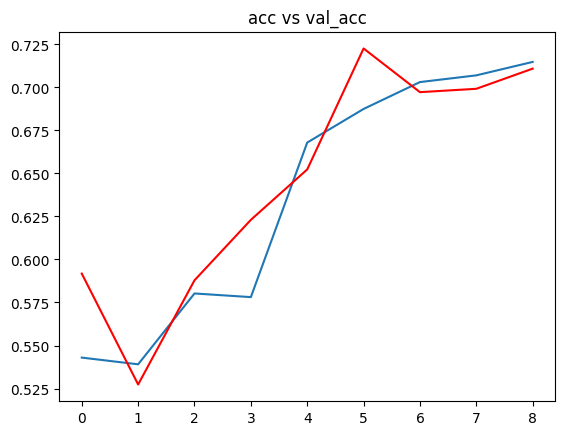

In [23]:
plt.plot(h['accuracy'])
plt.plot(h['val_accuracy'], c= 'red')
plt.title('acc vs val_acc')
plt.show()

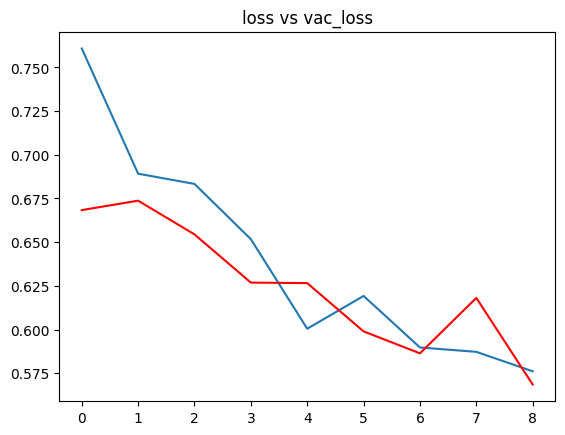

In [24]:
plt.plot(h['loss'])
plt.plot(h['val_loss'], c= 'red')
plt.title('loss vs vac_loss')
plt.show()

##MODEL ACCUracy


In [25]:
acc = model.evaluate(test_data)[1]
print(f"The accuracy of the model is {acc*100}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 405ms/step - accuracy: 0.7562 - loss: 0.5536
The accuracy of the model is 75.61683654785156%


In [26]:
import numpy as np
from keras.layers import Flatten,Dense
from keras.models import Model,load_model
from keras.applications.mobilenet import preprocess_input
from keras.applications.mobilenet import MobileNet
from keras.preprocessing.image import load_img,img_to_array

In [27]:
def preprocessingImages1(path):
    """
    input : Path
    output : Pre processed images
    """
    image_data = ImageDataGenerator(zoom_range= 0.2, shear_range= 0.2,preprocessing_function=preprocess_input, horizontal_flip= True)
    image = image_data.flow_from_directory(directory = path, target_size = (224,224), batch_size = 32, class_mode = 'binary')

    return image

In [28]:
path = "/content/train"
train_data = preprocessingImages1(path)

Found 3219 images belonging to 2 classes.


In [29]:
def preprocessingImages2(path):
    """
    input : Path
    output : Pre processed images
    """
    image_data = ImageDataGenerator(preprocessing_function=preprocess_input)
    image = image_data.flow_from_directory(directory = path, target_size = (224,224), batch_size = 32, class_mode = 'binary')

    return image

In [30]:
path = "/content/test"
test_data = preprocessingImages2(path)

Found 689 images belonging to 2 classes.


In [31]:
path = "/content/val"
val_data = preprocessingImages2(path)

Found 689 images belonging to 2 classes.


In [32]:
base_model = MobileNet(input_shape=(224,224,3), include_top=False)

17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [33]:
for layer in base_model.layers:
    layer.trainable = False

In [34]:
x = Flatten()(base_model.output)
x = Dense(units=1, activation='sigmoid')(x)
model = Model(base_model.input, x)

In [35]:
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,279,041 (12.51 MB)

 Trainable params: 50,177 (196.00 KB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [36]:
model.compile(optimizer= 'rmsprop', loss= keras.losses.binary_crossentropy, metrics= ['accuracy'])

In [37]:
##call backs

In [38]:
from keras.callbacks import EarlyStopping, ModelCheckpoint
mc = ModelCheckpoint(filepath= "best_model.h5", monitor= 'val_accuracy', verbose= 1, save_best_only= True, mode = 'auto')
es = EarlyStopping(monitor= 'val_accuracy', min_delta= 0.01, patience=3,verbose=1)
cb = [mc,es]

In [39]:
hist = model.fit(train_data, steps_per_epoch=8, epochs=30, validation_data=val_data, validation_steps=16, callbacks=cb)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - accuracy: 0.5917 - loss: 6.4453
Epoch 1: val_accuracy improved from None to 0.87695, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6016 - loss: 6.9536 - val_accuracy: 0.8770 - val_loss: 0.6641
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7845 - loss: 1.8025
Epoch 2: val_accuracy did not improve from 0.87695
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.7773 - loss: 1.9896 - val_accuracy: 0.8086 - val_loss: 1.4068
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.8977 - loss: 0.6727
Epoch 3: val_accuracy improved from 0.87695 to 0.90820, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 546ms/step - accuracy: 0.9023 - loss: 0.5733 - val_accuracy: 0.9082 - val_loss: 0.4376
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.7947 - loss: 1.6864
Epoch 4: val_accuracy improved from 0.90820 to 0.92969, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.7617 - loss: 2.3578 - val_accuracy: 0.9297 - val_loss: 0.4026
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8810 - loss: 0.6671
Epoch 5: val_accuracy improved from 0.92969 to 0.94336, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 673ms/step - accuracy: 0.8945 - loss: 0.5590 - val_accuracy: 0.9434 - val_loss: 0.1918
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9083 - loss: 0.7663
Epoch 6: val_accuracy did not improve from 0.94336
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.8047 - loss: 1.8857 - val_accuracy: 0.9297 - val_loss: 0.3637
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9171 - loss: 0.4731
Epoch 7: val_accuracy did not improve from 0.94336
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 497ms/step - accuracy: 0.9023 - loss: 0.5448 - val_accuracy: 0.8379 - val_loss: 1.3562
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.9278 - loss: 0.2806
Epoch 8: val_accuracy improved from 0.94336 to 0.96680, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 721ms/step - accuracy: 0.9414 - loss: 0.2532 - val_accuracy: 0.9668 - val_loss: 0.2229
Epoch 9/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.9343 - loss: 0.4284
Epoch 9: val_accuracy did not improve from 0.96680
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.8438 - loss: 1.5549 - val_accuracy: 0.8633 - val_loss: 1.0585
Epoch 10/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9263 - loss: 1.1063   
Epoch 10: val_accuracy did not improve from 0.96680
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9300 - loss: 0.7377 - val_accuracy: 0.9492 - val_loss: 0.2557
Epoch 11/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.9408 - loss: 0.2735
Epoch 11: val_accuracy did not improve from 0.96680
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 402ms/step - accuracy: 0.9297 - loss: 0.3735 - val_accuracy: 0.9648 - val_loss: 0.1671
Epoch 11: early stopping


In [40]:
#load best model
model = load_model("/content/best_model.h5")

In [41]:
acc = model.evaluate(test_data)[1]
print(f"The accuracy of the model is {acc*100}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 466ms/step - accuracy: 0.9637 - loss: 0.1654
The accuracy of the model is 96.37155532836914%


In [42]:
#Cheak some data

In [43]:
from keras.preprocessing import image

In [44]:
# path for the image to see if it predics correct class

path = "/content/BrainTumorData/Brain Tumor Data Set/Brain Tumor/Cancer (1).png"
img = image.load_img(path, target_size=(224,224) )

i = image.img_to_array(img)/255
input_arr = np.array([i])
input_arr.shape

pred = np.argmax(model.predict(input_arr)) #

if pred == 0:
    print("The MRI image is of BRAIN TUMOR")
else:
    print("The MRI image is of Healthey brain")


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
The MRI image is of BRAIN TUMOR
